In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# House prices dataset
house_prices = [150000, 180000, 200000, 220000, 240000, 1000000, 150000]

# Calculate measures of center
mean_price = np.mean(house_prices)
median_price = np.median(house_prices)
mode_price = stats.mode(house_prices, keepdims=True)

# Display results
print(f"Mean Price: ${mean_price:,.2f}")
print(f"Median Price: ${median_price:,.2f}")
print(f"Mode Price: ${mode_price.mode[0]:,.2f}, Count: {mode_price.count[0]}")

Mean Price: $305,714.29
Median Price: $200,000.00
Mode Price: $150,000.00, Count: 2


Mean --> 789.0833333333334
Median --> 769.5
Ranges --> 1684
Standard deviation (std) --> 425.1862255399261


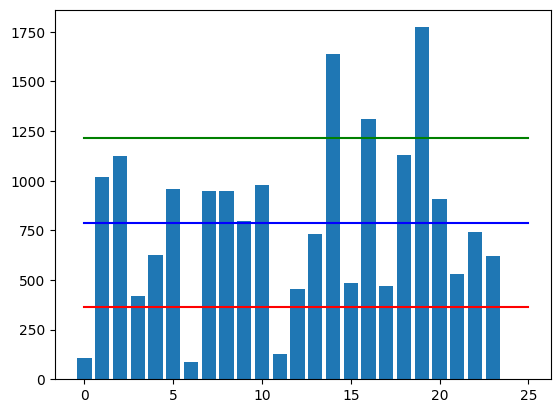

In [2]:
# We take a random sample of 24 of our friends on Facebook and wrote down how many friends that they had on Facebook.
import numpy as np



friends = [109, 1017, 1127, 418, 625, 957, 89, 950, 946, 797, 981,
           125, 455, 731, 1640, 485, 1309, 472, 1132, 1773, 906, 531, 742, 621]

print("Mean -->",np.mean(friends))
print("Median -->",np.median(friends))

ranges = np.max(friends) - np.min(friends)
std = np.std(friends) # == 425.2

print("Ranges -->",ranges)
print("Standard deviation (std) -->",std)

import matplotlib.pyplot as plt
%matplotlib inline
y_pos = range(len(friends))
plt.bar(y_pos, friends)
plt.plot((0, 25), (789, 789), 'b-') # the center
plt.plot((0, 25), (789+425, 789+425), 'g-') # the mean plus the standard deviation
plt.plot((0, 25), (789-425, 789-425), 'r-') # the mean minus the standard deviation

# the data lives between the green and the red lines while the outliers live outside the lines.

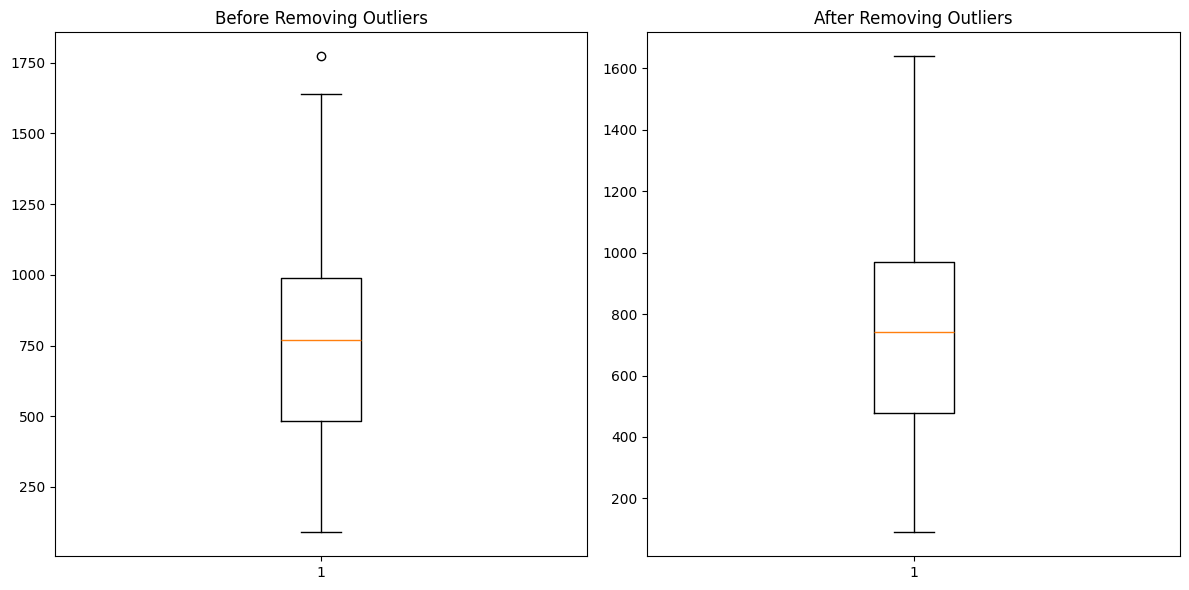

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Given data
friends = [109, 1017, 1127, 418, 625, 957, 89, 950, 946, 797, 981, 
           125, 455, 731, 1640, 485, 1309, 472, 1132, 1773, 906, 531, 
           742, 621]

# Step 1: Calculate Q1, Q3, and IQR
Q1 = np.percentile(friends, 25)
Q3 = np.percentile(friends, 75)
IQR = Q3 - Q1

# Step 2: Calculate lower and upper bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Step 3: Remove outliers
filtered_friends = [x for x in friends if lower_bound <= x <= upper_bound]

# Plotting before and after removing outliers
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

# Before removing outliers
ax1.boxplot(friends)
ax1.set_title("Before Removing Outliers")

# After removing outliers
ax2.boxplot(filtered_friends)
ax2.set_title("After Removing Outliers")

plt.tight_layout()
plt.show()


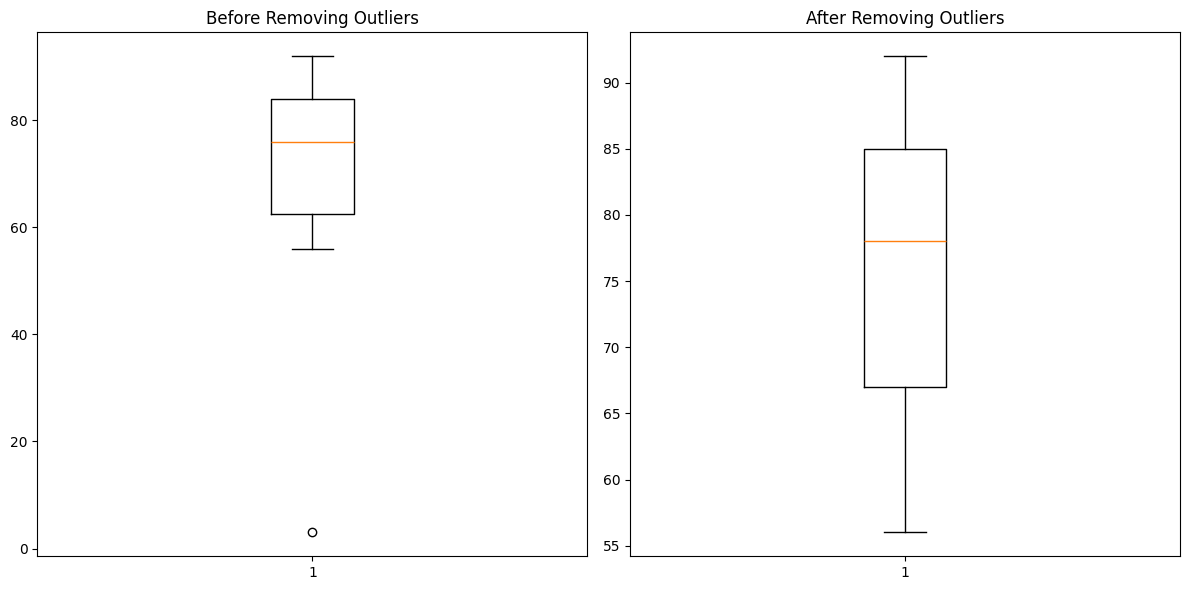

In [12]:
Scores=[56,78,85,92,61,74,88,3,67,81]



# Step 1: Calculate Q1, Q3, and IQR
Q1 = np.percentile(Scores, 25)
Q3 = np.percentile(Scores, 75)
IQR = Q3 - Q1

# Step 2: Calculate lower and upper bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Step 3: Remove outliers
filtered_Scores = [x for x in Scores if lower_bound <= x <= upper_bound]

# Plotting before and after removing outliers
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

# Before removing outliers
ax1.boxplot(Scores)
ax1.set_title("Before Removing Outliers")

# After removing outliers
ax2.boxplot(filtered_Scores)
ax2.set_title("After Removing Outliers")

plt.tight_layout()
plt.show()


<BarContainer object of 24 artists>

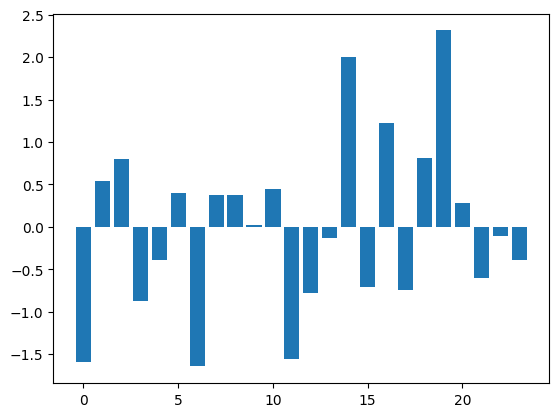

In [13]:
z_scores = []
m = np.mean(friends) # average friends on Facebook
s = np.std(friends) # standard deviation friends on Facebook
for friend in friends:
    z = (friend - m)/s # z-score
    z_scores.append(z) # make a list of the scores for plotting

plt.bar(y_pos, z_scores)

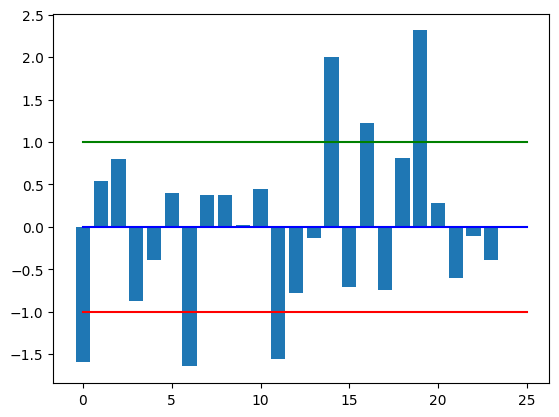

In [15]:
plt.bar(y_pos, z_scores)
plt.plot((0, 25), (1, 1), 'g-') # zero standard deviations away from the mean
plt.plot((0, 25), (0, 0), 'b-') # represents one standard deviation above the mean
plt.plot((0, 25), (-1, -1), 'r-') # one standard deviation below the mean

   friends  happiness
0      109        0.8
1     1017        0.6
2     1127        0.3
3      418        0.6
4      625        0.6


<Axes: xlabel='friends_scaled', ylabel='happiness_scaled'>

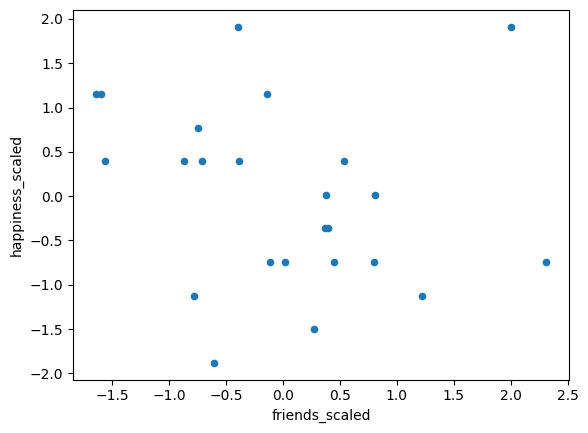

In [20]:
import pandas as pd
from sklearn import preprocessing

happiness = [.8, .6, .3, .6, .6, .4, .8, .5, .4, .3, .3, .6, .2, .8,
1, .6, .2, .7, .5, .3, .1, 0, .3, 1]

df = pd.DataFrame({'friends':friends, 'happiness':happiness})
print(df.head())

## Steps for z score
# Finding the mean of the column
# Finding the standard deviation of the column
# Applying the z-score function to each element in the column
df_scaled = pd.DataFrame(preprocessing.scale(df), columns = ['friends_scaled', 'happiness_scaled'])
df_scaled.head()

df_scaled.plot(kind='scatter', x = 'friends_scaled', y = 'happiness_scaled')

In [21]:

df.corr()

,friends,happiness
friends,1.000000,-0.216199
happiness,-0.216199,1.000000


In [22]:

# finding the percentage of people within one standard deviation ofthe mean
within_1_std = df_scaled[(df_scaled['friends_scaled'] <= 1) & (df_scaled['friends_scaled'] >= -1)].shape[0]
print("within 1 std",within_1_std / float(df_scaled.shape[0]))
# 0.75
# finding the percentage of people within two standard deviations of the mean
within_2_std = df_scaled[(df_scaled['friends_scaled'] <= 2) & (df_scaled['friends_scaled'] >= -2)].shape[0]
print("within 2 std",within_2_std / float(df_scaled.shape[0]))
# 0.916
# finding the percentage of people within three standard deviations of the mean
within_3_std = df_scaled[(df_scaled['friends_scaled'] <= 3) & (df_scaled['friends_scaled'] >= -3)].shape[0]
print("within 3std",within_3_std / float(df_scaled.shape[0]))
# 1.0

within 1 std 0.75
within 2 std 0.9166666666666666
within 3std 1.0


array([[<Axes: title={'center': '0'}>]], dtype=object)

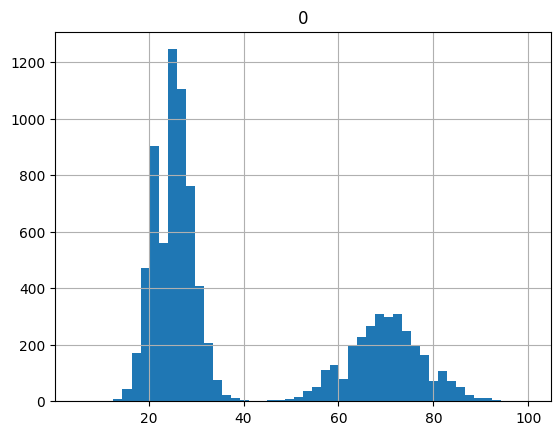

In [3]:
import numpy as np
from scipy import stats
import pandas as pd
np.random.seed(1234)
long_breaks = stats.poisson.rvs(loc=10, mu=60, size=3000)
short_breaks = stats.poisson.rvs(loc=10, mu=15, size=6000)
breaks = np.concatenate((long_breaks, short_breaks))
pd.DataFrame(breaks).hist(bins=50,range=(5,100))

array([[<Axes: title={'center': '0'}>]], dtype=object)

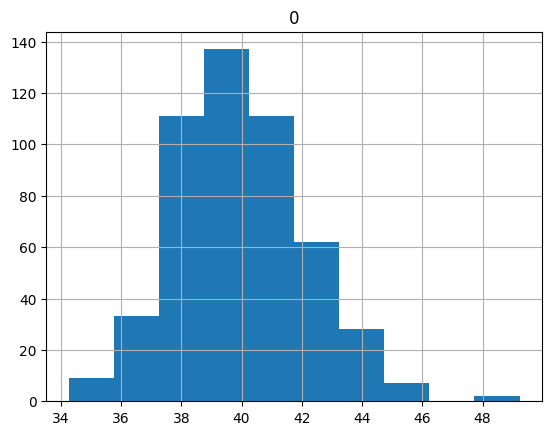

In [4]:
point_estimates = []
for x in range(500): # Generate 500 samples
    sample = np.random.choice(a= breaks, size=100)
#take a sample of 100 points
    point_estimates.append( sample.mean() )
# add the sample mean to our list of point estimates
pd.DataFrame(point_estimates).hist()
# look at the distribution of our sample

In [13]:
import math

sample_size = 100
# the size of the sample we wish to take
sample = np.random.choice(a= breaks, size = sample_size)
# a sample of sample_size taken from the 9,000 breaks population from before
sample_mean = sample.mean()
# the sample mean of the break lengths sample
sample_stdev = sample.std()
# sample standard deviation
sigma = sample_stdev/math.sqrt(sample_size)
# population standard deviation estimate


stats.t.interval(confidence = 0.95, # Confidence level 95%
                 df= sample_size - 1, # Degrees of freedom
                 loc = sample_mean, # Sample mean
                scale = sigma) # Standard deviation


(np.float64(34.513579161034194), np.float64(43.0064208389658))

In [14]:
# function to make confidence interval
def makeConfidenceInterval():
    sample_size = 100
    sample = np.random.choice(a= breaks, size = sample_size)
    sample_mean = sample.mean()
    # sample mean
    sample_stdev = sample.std()
    # sample standard deviation
    sigma = sample_stdev/math.sqrt(sample_size)
    # population Standard deviation estimate
    return stats.t.interval(confidence= 0.95, df= sample_size - 1, loc =
    sample_mean, scale = sigma)

times_in_interval = 0.

for i in range(1000):
    interval = makeConfidenceInterval()
    if 39.99 >= interval[0] and 39.99 <= interval[1]:
    # if 39.99 falls in the interval
        times_in_interval += 1
print(times_in_interval)
print(times_in_interval / 1000)

954.0
0.954


In [15]:
for confidence in (.5, .8, .85, .9, .95, .99):
    confidence_interval = stats.t.interval(confidence= confidence, df=sample_size - 1, loc = sample_mean, scale = sigma)
    length_of_interval = round(confidence_interval[1] - confidence_interval[0], 2)
# the length of the confidence interval
    print("confidence {0} has a interval of size {1}".format(confidence, length_of_interval))

confidence 0.5 has a interval of size 2.9
confidence 0.8 has a interval of size 5.52
confidence 0.85 has a interval of size 6.21
confidence 0.9 has a interval of size 7.11
confidence 0.95 has a interval of size 8.49
confidence 0.99 has a interval of size 11.24


In [16]:
import scipy.stats as stats
import numpy as np

# Define the population mean weight
population_mean = 45

# Define the sample mean weight and standard deviation
sample_mean = 75
sample_std = 25

# Define the sample size
sample_size = 25


# Calculate the t-statistic
t_statistic = (sample_mean - population_mean) / (sample_std / np.sqrt(sample_size))

# Define the degrees of freedom
df = sample_size - 1

# Set the significance level (alpha)
alpha = 0.05

# Calculate the critical t-value
critical_t = stats.t.ppf(1 - alpha, df)

# Calculate the p-value
p_value = 1 - stats.t.cdf(t_statistic, df)

# Print the results
print("T-Statistic:", t_statistic)
print("Critical t-value:", critical_t)
print("P-Value:", p_value)

# Decision
print('With T-value :')
if t_statistic > critical_t:
    print("""There is a significant difference in weight before and after the camp. 
    The fitness camp had an effect.""")
else:
    print("""There is no significant difference in weight before and after the camp. 
    The fitness camp did not have a significant effect.""")

print('With P-value :')
if p_value >alpha:
    print("""There is a significant difference in weight before and after the camp. 
    The fitness camp had an effect.""")
else:
    print("""There is no significant difference in weight before and after the camp. 
    The fitness camp did not have a significant effect.""")

T-Statistic: 6.0
Critical t-value: 1.7108820799094275
P-Value: 1.703654035845048e-06
With T-value :
There is a significant difference in weight before and after the camp. 
    The fitness camp had an effect.
With P-value :
There is no significant difference in weight before and after the camp. 
    The fitness camp did not have a significant effect.


In [17]:
# import the necessary libraries
from scipy import stats
import numpy as np

# Sample
sample_A = np.array([78,84,92,88,75,80,85,90,87,7978,84,92,88,75,80,85,90,87,79])
sample_B = np.array([82,88,75,90,78,85,88,77,92,8082,88,75,90,78,85,88,77,92,80])

# Perform independent sample t-test
t_statistic, p_value = stats.ttest_ind(sample_A, sample_B)

# Set the significance level (alpha)
alpha = 0.05

# Compute the degrees of freedom (df) (n_A-1)+(n_b-1)
df = len(sample_A)+len(sample_B)-2

# Calculate the critical t-value
# ppf is used to find the critical t-value for a two-tailed test
critical_t = stats.t.ppf(1 - alpha/2, df)


# Print the results
# print("T-value:", t_statistic)
print("P-Value:", p_value)
print("Critical t-value:", critical_t)
print('With P-value')
if p_value >alpha:
    print('No evidence to reject the null hypothesis that a significant difference between the two groups')
else:

    print('Evidence found to reject the null hypothesis that a significant difference between the two groups')


P-Value: 0.9934425963209128
Critical t-value: 2.0280940009804502
With P-value
No evidence to reject the null hypothesis that a significant difference between the two groups


In [22]:
group_X = np.array([85, 92, 87, 90, 88, 83, 86, 89, 91, 84])
group_Y = np.array([80, 85, 78, 88, 83, 87, 86, 82, 89, 84])

In [24]:
# Import necessary libraries
import numpy as np
from scipy import stats

# Sample data (1D arrays)
group_x = np.array([85, 92, 87, 90, 88, 83, 86, 89, 91, 84])
group_y = np.array([80, 85, 78, 88, 83, 87, 86, 82, 89, 84])

# Perform independent samples t-test
t_statistic, p_value = stats.ttest_ind(group_x, group_y)

# Significance level
alpha = 0.05

# Degrees of freedom: (n1 + n2 - 2)
df = len(group_x) + len(group_y) - 2

# Critical t-value for two-tailed test
critical_t = stats.t.ppf(1 - alpha / 2, df)

# Print results
print("T-statistic:", t_statistic)
print("P-value:", p_value)
print("Degrees of freedom:", df)
print("Critical t-value:", critical_t)

# Decision using p-value
print("\nDecision:")
if p_value > alpha:
    print("No evidence to reject the null hypothesis.")
    print("There is no significant difference between the two groups.")
else:
    print("Reject the null hypothesis.")
    print("There is a significant difference between the two groups.")


T-statistic: 2.2471001405658484
P-value: 0.03741242338800086
Degrees of freedom: 18
Critical t-value: 2.10092204024096

Decision:
Reject the null hypothesis.
There is a significant difference between the two groups.


In [25]:
import numpy as np
from scipy.stats import chi2_contingency

# Define the contingency table
data = np.array([[20, 15, 10],  # Male
                 [25, 20, 30]]) # Female

# Perform the Chi-Square test
chi2_stat, p_value, dof, expected = chi2_contingency(data)

# Print the results
print(f"Chi-Square Statistic: {chi2_stat:.4f}")
print(f"P-Value: {p_value:.4f}")
print(f"Degrees of Freedom: {dof}")
print("Expected Frequencies Table:")
print(expected)

# Interpretation
alpha = 0.05  # Significance level
if p_value < alpha:
    print("Reject the null hypothesis: There is a significant relationship between gender and ice cream preference.")
else:
    print("Fail to reject the null hypothesis: No significant relationship between gender and ice cream preference.")

Chi-Square Statistic: 4.0212
P-Value: 0.1339
Degrees of Freedom: 2
Expected Frequencies Table:
[[16.875 13.125 15.   ]
 [28.125 21.875 25.   ]]
Fail to reject the null hypothesis: No significant relationship between gender and ice cream preference.


In [26]:
from scipy.stats import f_oneway

e = [2,4,2]
m = [2,3,4]
s = [1,2,5]

In [27]:
stats, f_value = f_oneway(e,m,s)
alpha = 0.05

if (f_value < alpha):
    print("reject null hypothesis")
else:
    print("fail to reject null hypothesis")

fail to reject null hypothesis


In [28]:
performance_1 = [89, 89, 88, 78, 79]
performance_2 = [93, 92, 94, 89, 88]
performance_3 = [89, 88, 89, 93, 90]
performance_4 = [81, 78, 81, 92, 82]
stats, f_value = f_oneway(performance_2 ,performance_2 ,performance_3 ,performance_4 )
alpha=0.05
if (f_value < alpha):
    print("reject null hypothesis")
else:
    print("fail to reject null hypothesis")


reject null hypothesis


In [1]:
import pandas as pd
import numpy as np

data = {
    'Age': [25, 30, np.nan, 35, 40, np.nan, 45],
    'Salary': [50000, np.nan, 70000, np.nan, 90000, 120000, 110000],
    'Gender': ['Male', 'Female', np.nan, 'Female', 'Male', 'Male', np.nan],
    'Experience': [1, 3, 5, np.nan, 10, 15, np.nan]
}

df = pd.DataFrame(data)
print("Original DataFrame with Missing Values:")
print(df)

Original DataFrame with Missing Values:
    Age    Salary  Gender  Experience
0  25.0   50000.0    Male         1.0
1  30.0       NaN  Female         3.0
2   NaN   70000.0     NaN         5.0
3  35.0       NaN  Female         NaN
4  40.0   90000.0    Male        10.0
5   NaN  120000.0    Male        15.0
6  45.0  110000.0     NaN         NaN


In [2]:

print(df.isnull().sum())  # Shows count of missing values per column

Age           2
Salary        2
Gender        2
Experience    2
dtype: int64


In [3]:
df_dropped_rows = df.dropna()
print("\nDataFrame after dropping rows with missing values:")
print(df_dropped_rows)


DataFrame after dropping rows with missing values:
    Age   Salary Gender  Experience
0  25.0  50000.0   Male         1.0
4  40.0  90000.0   Male        10.0


In [ ]:
# Impute missing values with the median
df_median = df
df_median['Age'].fillna(df_median['Age'].median(), inplace=True)
df_median['Salary'].fillna(df_median['Salary'].median(), inplace=True)
df_median['Experience'].fillna(df_median['Experience'].median(), inplace=True)

print("\nDataFrame after imputing numerical columns with mean:")
print(df_median)


DataFrame after imputing numerical columns with mean:
    Age    Salary  Gender  Experience
0  25.0   50000.0    Male         1.0
1  30.0   88000.0  Female         3.0
2  35.0   70000.0     NaN         5.0
3  35.0   88000.0  Female         6.8
4  40.0   90000.0    Male        10.0
5  35.0  120000.0    Male        15.0
6  45.0  110000.0     NaN         6.8


In [8]:
df_median['Age'].median()

np.float64(35.0)

In [7]:

# Impute missing values with the mean
df_mean = df
df_mean['Age'].fillna(df_mean['Age'].mean(), inplace=True)
df_mean['Salary'].fillna(df_mean['Salary'].mean(), inplace=True)
df_mean['Experience'].fillna(df_mean['Experience'].mean(), inplace=True)

print("\nDataFrame after imputing numerical columns with mean:")
print(df_mean)


DataFrame after imputing numerical columns with mean:
    Age    Salary  Gender  Experience
0  25.0   50000.0    Male         1.0
1  30.0   88000.0  Female         3.0
2  35.0   70000.0     NaN         5.0
3  35.0   88000.0  Female         6.8
4  40.0   90000.0    Male        10.0
5  35.0  120000.0    Male        15.0
6  45.0  110000.0     NaN         6.8


In [9]:
df_mean['Age'].mean()

np.float64(35.0)

In [10]:
df_mode = df
df_mode['Gender'].fillna(df_mode['Gender'].mode()[0], inplace=True)


print("\nDataFrame after imputing categorical columns with mode:")
print(df_mode)


DataFrame after imputing categorical columns with mode:
    Age    Salary  Gender  Experience
0  25.0   50000.0    Male         1.0
1  30.0   88000.0  Female         3.0
2  35.0   70000.0    Male         5.0
3  35.0   88000.0  Female         6.8
4  40.0   90000.0    Male        10.0
5  35.0  120000.0    Male        15.0
6  45.0  110000.0    Male         6.8


In [11]:
import pandas as pd

# Sample DataFrame
df = pd.DataFrame({
    'Price': [10, 20, 15, 18, 25],
    'Color': ['Red', 'Blue', None, 'Green', 'Red'],
    'Size': [None, 'M', 'L', 'S', 'M']
})


df['Color'] = df['Color'].fillna(df['Color'].mode()[0])  # Most frequent value
df['Size'] = df['Size'].fillna(df['Size'].mode()[0])  # Most frequent value

print(df)

   Price  Color Size
0     10    Red    M
1     20   Blue    M
2     15    Red    L
3     18  Green    S
4     25    Red    M


In [12]:

# Label Encoding  vs ordinal Encoding 

from sklearn.preprocessing import LabelEncoder

# Apply Label Encoding to 'Size'
label_encoder = LabelEncoder()
df['Size'] = label_encoder.fit_transform(df['Size'])

print("\nDataFrame after Label Encoding for 'Size':\n", df)


DataFrame after Label Encoding for 'Size':
    Price  Color  Size
0     10    Red     1
1     20   Blue     1
2     15    Red     0
3     18  Green     2
4     25    Red     1


types pf encoding

1.label encoding

2.ordinary encoding

3.one hot encoding

In [13]:
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder


# Define the preprocessor
preprocessor = ColumnTransformer(
    transformers=[('onehot', OneHotEncoder(), ['Color'])],  # Use column names
    remainder='passthrough'  # Keep numerical columns as they are
)

# Apply the transformation
transformed_data = preprocessor.fit_transform(df)

# Convert back to DataFrame with feature names
feature_names = preprocessor.get_feature_names_out()
df_encoded = pd.DataFrame(transformed_data, columns=feature_names)

print(df_encoded)

   onehot__Color_Blue  onehot__Color_Green  onehot__Color_Red  \
0                 0.0                  0.0                1.0   
1                 1.0                  0.0                0.0   
2                 0.0                  0.0                1.0   
3                 0.0                  1.0                0.0   
4                 0.0                  0.0                1.0   

   remainder__Price  remainder__Size  
0              10.0              1.0  
1              20.0              1.0  
2              15.0              0.0  
3              18.0              2.0  
4              25.0              1.0  


In [14]:

import numpy as np
import pandas as pd

# Creating a dataset with different types of values
np.random.seed(42)
data = {
    'Feature_1': np.random.randint(10, 100, 10),    # Random integers (positive)
    'Feature_2': np.random.randn(10) * 10,         # Normally distributed values
    'Feature_3': np.random.exponential(5, 10),     # Skewed data (exponential)
    'Feature_4': np.random.randint(-50, 50, 10),   # Positive & Negative values
    'Feature_5': [5, 10, 15, 1000, 20, 25, 30, 35, 40, 45]  # Outlier in the middle
}

df = pd.DataFrame(data)
print("Original Dataset:\n", df)

Original Dataset:
    Feature_1  Feature_2  Feature_3  Feature_4  Feature_5
0         61  -8.852303   0.238948         22          5
1         24  -4.121885  18.201498        -12         10
2         81  -4.826188   1.324852        -33         15
3         70   1.641648   0.474887        -47       1000
4         30   2.330952   4.816728         38         20
5         92   1.179946   2.410073          9         25
6         96  14.623781  20.441083        -37         30
7         84  15.387150   3.143946        -42         35
8         84 -24.391058   9.828436         39         40
9         97   6.034412   5.701979          2         45


In [19]:

from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, MaxAbsScaler

# Initialize scalers
standard_scaler = StandardScaler()
minmax_scaler = MinMaxScaler()
robust_scaler = RobustScaler()
maxabs_scaler = MaxAbsScaler()

# Apply scalers
df_standard = pd.DataFrame(standard_scaler.fit_transform(df), columns=df.columns)
df_minmax = pd.DataFrame(minmax_scaler.fit_transform(df), columns=df.columns)
df_robust = pd.DataFrame(robust_scaler.fit_transform(df), columns=df.columns)
df_maxabs = pd.DataFrame(maxabs_scaler.fit_transform(df), columns=df.columns)

# Log Transformation (Handling zero by adding 1)
df_log = np.log1p(df)

# Display results
print("\nStandard Scaled Data:\n", df_standard)
print("\nMinMax Scaled Data:\n", df_minmax)
print("\nRobust Scaled Data:\n", df_robust)
print("\nMaxAbs Scaled Data:\n", df_maxabs)
print("\nLog Transformed Data:\n", df_log)


Standard Scaled Data:
    Feature_1  Feature_2  Feature_3  Feature_4  Feature_5
0  -0.439070  -0.795715  -0.930574   0.900525  -0.401358
1  -1.929492  -0.365681   1.673370  -0.189078  -0.384279
2   0.366563  -0.429708  -0.773156  -0.862069  -0.367200
3  -0.076535   0.158271  -0.896371  -1.310729   2.997374
4  -1.687802   0.220935  -0.266956   1.413280  -0.350121
5   0.809662   0.116299  -0.615837   0.483912  -0.333042
6   0.970788   1.338453   1.998032  -0.990257  -0.315962
7   0.487408   1.407850  -0.509451  -1.150493  -0.298883
8   0.487408  -2.208314   0.459568   1.445327  -0.281804
9   1.011070   0.557610  -0.138625   0.259582  -0.264725

MinMax Scaled Data:
    Feature_1  Feature_2  Feature_3  Feature_4  Feature_5
0   0.506849   0.390635   0.000000   0.802326   0.000000
1   0.000000   0.509555   0.889141   0.406977   0.005025
2   0.780822   0.491849   0.053752   0.162791   0.010050
3   0.630137   0.654446   0.011679   0.000000   1.000000
4   0.082192   0.671775   0.226599   0.988

c:\Users\LOQ\AppData\Local\Programs\Python\Python314\Lib\site-packages\pandas\core\internals\blocks.py:395: RuntimeWarning: invalid value encountered in log1p
  result = func(self.values, **kwargs)


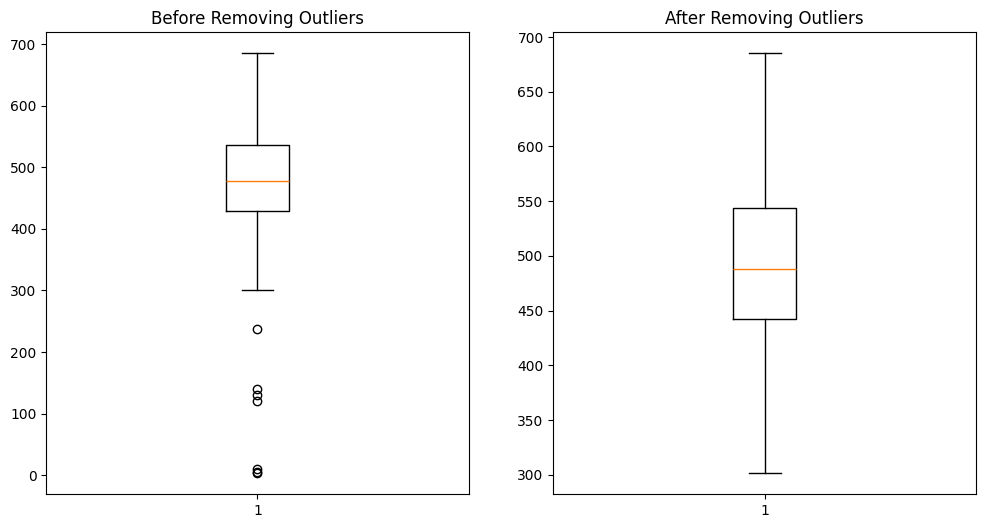

Data after removing outliers:
        Value
0  549.671415
1  486.173570
2  564.768854
3  652.302986
4  476.584663


In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Generate some random data
np.random.seed(42)
data = np.random.normal(loc=500, scale=100, size=100)  # Normal distribution

# Add extreme outliers (including very low values)
outliers = np.array([10, 120, 130, 5, 140, 3])
data_with_outliers = np.concatenate([data, outliers])

# Convert to DataFrame
df = pd.DataFrame({'Value': data_with_outliers})

# Calculate Q1, Q3, and IQR
Q1 = df['Value'].quantile(0.25)
Q3 = df['Value'].quantile(0.75)
IQR = Q3 - Q1

# Define lower and upper bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Remove outliers
df_filtered = df[(df['Value'] >= lower_bound) & (df['Value'] <= upper_bound)]

# Plot before and after removing outliers
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

ax1.boxplot(df['Value'])
ax1.set_title("Before Removing Outliers")

ax2.boxplot(df_filtered['Value'])
ax2.set_title("After Removing Outliers")

plt.show()

print("Data after removing outliers:")
print(df_filtered.head())

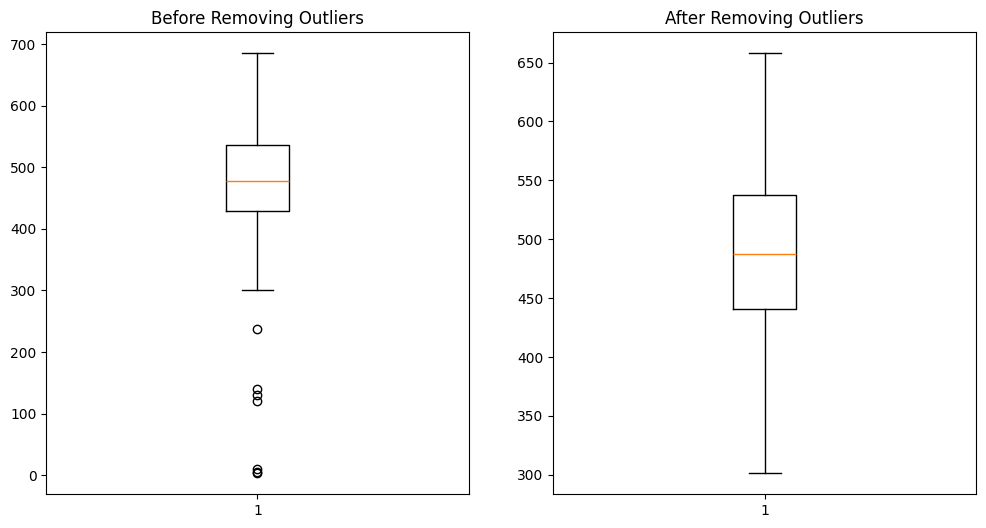

Data after removing outliers (Z-score method):
        Value
0  549.671415
1  486.173570
2  564.768854
3  652.302986
4  476.584663


In [24]:
from sklearn.preprocessing import StandardScaler

# Reshape data for scaling
data_reshaped = df[['Value']].values  

# Use StandardScaler to compute Z-scores
scaler = StandardScaler()
z_scores = scaler.fit_transform(data_reshaped)

# Define a threshold (commonly 3)
threshold = 1.5
df_filtered_z = df[np.abs(z_scores) < threshold]

# Plot before and after removing outliers
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

ax1.boxplot(df['Value'])
ax1.set_title("Before Removing Outliers")

ax2.boxplot(df_filtered_z['Value'])
ax2.set_title("After Removing Outliers")

plt.show()

print("Data after removing outliers (Z-score method):")
print(df_filtered_z.head())

In [26]:
import pandas as pd

def load_housing_data(HOUSING_PATH):
 return pd.read_csv(HOUSING_PATH)

housing = load_housing_data("housing.csv")
housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [27]:
housing.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [28]:
# Handling Text and Categorical Attributes

housing["ocean_proximity"].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

In [30]:

housing_new = housing.drop(columns=['ocean_proximity'])

In [31]:
corr_matrix = housing_new.corr()
# check the correlation in descending order
corr_matrix["median_house_value"].sort_values(ascending=False)

median_house_value    1.000000
median_income         0.688075
total_rooms           0.134153
housing_median_age    0.105623
households            0.065843
total_bedrooms        0.049686
population           -0.024650
longitude            -0.045967
latitude             -0.144160
Name: median_house_value, dtype: float64

In [32]:
 # creating own features and  check whether its correlation
housing_new["rooms_per_household"] = housing_new["total_rooms"]/housing_new["households"]
housing_new["bedrooms_per_room"] = housing_new["total_bedrooms"]/housing_new["total_rooms"]
housing_new["population_per_household"]=housing_new["population"]/housing_new["households"]


# checking over the correlation of median house price with other features
corr_matrix = housing_new.corr()
corr_matrix["median_house_value"].sort_values(ascending=False)

median_house_value          1.000000
median_income               0.688075
rooms_per_household         0.151948
total_rooms                 0.134153
housing_median_age          0.105623
households                  0.065843
total_bedrooms              0.049686
population_per_household   -0.023737
population                 -0.024650
longitude                  -0.045967
latitude                   -0.144160
bedrooms_per_room          -0.255880
Name: median_house_value, dtype: float64

In [33]:
# Define the target and features
X = housing.drop('median_house_value', axis=1)  # Features (exclude target)
y = housing['median_house_value']  # Target
# Define numerical and categorical columns
housing_num = X.select_dtypes(include=['float64', 'int64']).columns
housing_cat = X.select_dtypes(include=['object']).columns

# Print out the column names to verify
print("Numerical columns:", housing_num)
print("Categorical columns:", housing_cat)

Numerical columns: Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income'],
      dtype='object')
Categorical columns: Index(['ocean_proximity'], dtype='object')


In [34]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline


from sklearn.impute import SimpleImputer

## Define the numerical pipeline
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),  # Handle missing values with median
    ('scaler', StandardScaler())  # Scale the numerical features
])

# Define the categorical pipeline
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),  # Handle missing categorical values
    ('onehot', OneHotEncoder(handle_unknown='ignore'))  # One-hot encode categorical features
])

# Combine both pipelines using ColumnTransformer
preprocessor = ColumnTransformer([
    ('num', num_pipeline, housing_num),  # Apply num_pipeline to numerical columns
    ('cat', cat_pipeline, housing_cat)   # Apply cat_pipeline to categorical columns
])

In [38]:
# Apply the transformation to the features (X)
X_transformed = preprocessor.fit_transform(X)

# Convert the result into a DataFrame (optional for better readability)
# Get the transformed column names for both numerical and categorical data
num_columns = housing_num
cat_columns = preprocessor.transformers_[1][1].named_steps['onehot'].get_feature_names_out(housing_cat)

# Combine column names and create a new DataFrame for the transformed data
all_columns = list(num_columns) + list(cat_columns)
X_transformed_df = pd.DataFrame(X_transformed, columns=all_columns)

# Display the transformed dataset
print(X_transformed_df.head())

   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0  -1.327835  1.052548            0.982143    -0.804819       -0.972476   
1  -1.322844  1.043185           -0.607019     2.045890        1.357143   
2  -1.332827  1.038503            1.856182    -0.535746       -0.827024   
3  -1.337818  1.038503            1.856182    -0.624215       -0.719723   
4  -1.337818  1.038503            1.856182    -0.462404       -0.612423   

   population  households  median_income  ocean_proximity_<1H OCEAN  \
0   -0.974429   -0.977033       2.344766                        0.0   
1    0.861439    1.669961       2.332238                        0.0   
2   -0.820777   -0.843637       1.782699                        0.0   
3   -0.766028   -0.733781       0.932968                        0.0   
4   -0.759847   -0.629157      -0.012881                        0.0   

   ocean_proximity_INLAND  ocean_proximity_ISLAND  ocean_proximity_NEAR BAY  \
0                     0.0                  

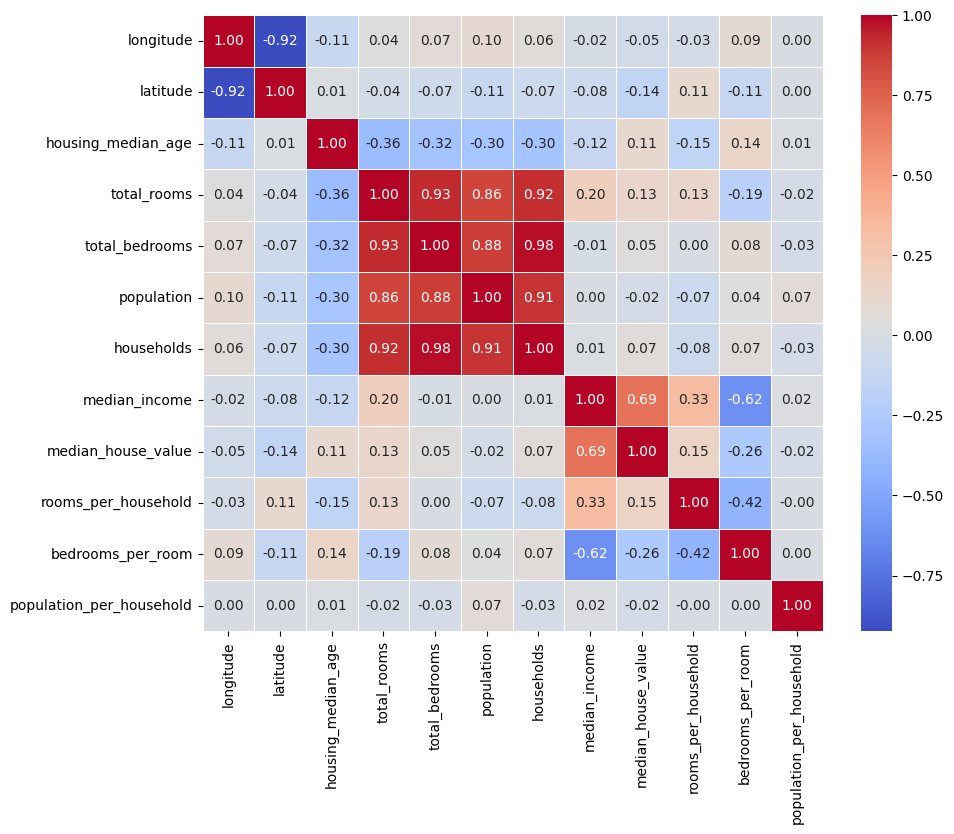

['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'median_house_value', 'rooms_per_household', 'bedrooms_per_room', 'population_per_household']


In [35]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate correlation matrix
corr_matrix = housing_new.corr()

# Plot heatmap of correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.show()

# Drop highly correlated features (e.g., correlation > 0.9)
corr_threshold = 0.9
to_drop = [column for column in corr_matrix.columns if any(abs(corr_matrix[column]) > corr_threshold)]
print(to_drop)

In [39]:
X = X_transformed_df

from sklearn.linear_model import LassoCV 
from sklearn.model_selection import train_test_split
# Create a LassoCV model
lasso = LassoCV(cv=5, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# Fit the model to the training data
lasso.fit(X_train, y_train)


# Print the best alpha value chosen by cross-validation
print(f"Best alpha: {lasso.alpha_}")
# Get the features selected by Lasso
selected_features = X.columns[lasso.coef_ != 0]
print(f"Selected features: {selected_features}")

Best alpha: 80.03944420610821
Selected features: Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'ocean_proximity_INLAND', 'ocean_proximity_NEAR BAY',
       'ocean_proximity_NEAR OCEAN'],
      dtype='object')


In [41]:
import pandas as pd

# Load the dataset
df = pd.read_csv("housing.csv")  # Replace with actual dataset path
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [42]:
from sklearn.preprocessing import StandardScaler

# Selecting numerical features
numerical_features = df.select_dtypes(include=['float64', 'int64']).drop(columns=['median_house_value'], errors='ignore')  # Drop target if applicable

# Standardizing the features
scaler = StandardScaler()
scaled_data = scaler.fit_transform(numerical_features)

In [43]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="mean")  # You can also use "median" or "most_frequent"
scaled_data = imputer.fit_transform(scaled_data)

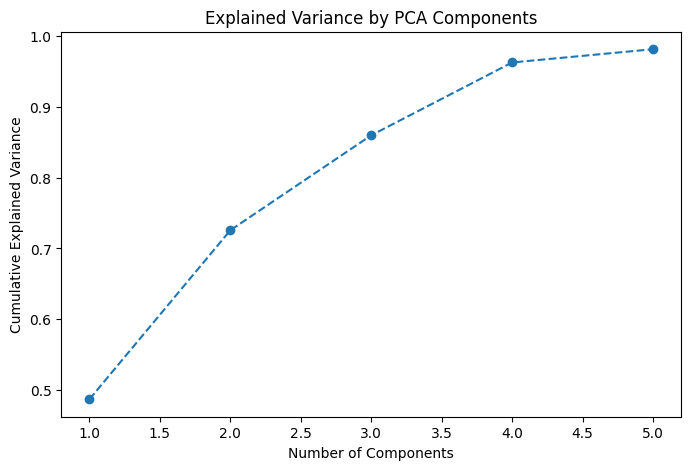

In [49]:
# manually 
from sklearn.decomposition import PCA

# Choose the number of components
pca = PCA(n_components=5)  # Adjust based on variance explained
pca_features = pca.fit_transform(scaled_data)

# Convert to DataFrame
pca_df = pd.DataFrame(pca_features, columns=[f'PC{i+1}' for i in range(5)])


import matplotlib.pyplot as plt

explained_variance = pca.explained_variance_ratio_

# Plot cumulative variance
plt.figure(figsize=(8,5))
plt.plot(range(1, len(explained_variance)+1), explained_variance.cumsum(), marker='o', linestyle='--')
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Explained Variance by PCA Components")
plt.show()

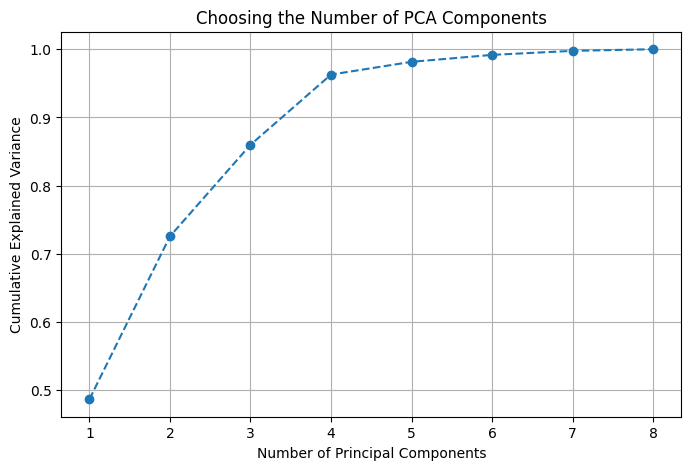

In [45]:

# automate the n component

from sklearn.decomposition import PCA
import numpy as np

# Apply PCA without specifying components (to analyze all)
pca = PCA()
pca.fit(scaled_data)

# Calculate cumulative variance explained
explained_variance = np.cumsum(pca.explained_variance_ratio_)

# Plot the explained variance
plt.figure(figsize=(8,5))
plt.plot(range(1, len(explained_variance) + 1), explained_variance, marker='o', linestyle='--')
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Choosing the Number of PCA Components")
plt.grid()
plt.show()

In [46]:

# Find the number of components that explain at least 95% variance
optimal_components = np.argmax(explained_variance >= 0.95) + 1
print(f"Optimal number of components: {optimal_components}")


pca = PCA(n_components=optimal_components)
pca

Optimal number of components: 4


,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",np.int64(4)
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for rando

In [1]:
import numpy as np
import matplotlib.pyplot as plt


In [2]:

## Prepare data
## 1.1 Get your X and y in the right shape

from sklearn.datasets import load_diabetes

diabetes = load_diabetes()

# diabetes #dictionary of numpy arrays - bunch

print("Features: ", diabetes.feature_names)

Features:  ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']


In [3]:
# features
X = diabetes.data
print(X.shape) #(442 = number of samples, 10 = features)(m, n)
X

(442, 10)


array([[ 0.03807591,  0.05068012,  0.06169621, ..., -0.00259226,
         0.01990749, -0.01764613],
       [-0.00188202, -0.04464164, -0.05147406, ..., -0.03949338,
        -0.06833155, -0.09220405],
       [ 0.08529891,  0.05068012,  0.04445121, ..., -0.00259226,
         0.00286131, -0.02593034],
       ...,
       [ 0.04170844,  0.05068012, -0.01590626, ..., -0.01107952,
        -0.04688253,  0.01549073],
       [-0.04547248, -0.04464164,  0.03906215, ...,  0.02655962,
         0.04452873, -0.02593034],
       [-0.04547248, -0.04464164, -0.0730303 , ..., -0.03949338,
        -0.00422151,  0.00306441]], shape=(442, 10))

In [4]:
m = X.shape[0] # # of samples
n = X.shape[1] # # of features
print(X[0])  #big letter X represents matrix

[ 0.03807591  0.05068012  0.06169621  0.02187239 -0.0442235  -0.03482076
 -0.04340085 -0.00259226  0.01990749 -0.01764613]


In [5]:

# target
y = diabetes.target

print(y.shape) #small letter y represents vector
print("values",y[0:3])
print(y[0])

(442,)
values [151.  75. 141.]
151.0


In [6]:

assert m == y.shape[0]

In [7]:
# 1.2 Split Train test split your data

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2)

In [8]:

y_test.shape

(89,)

In [9]:
# Feature scale your data to reach faster convergence
print(X_train[0])

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

[-0.04183994 -0.04464164  0.12852056  0.0631866  -0.03321588 -0.03262872
  0.01182372 -0.03949338 -0.01599887 -0.05078298]


In [10]:

X_train[0]

array([-0.92235899, -0.94217861,  2.7721013 ,  1.28544683, -0.71841724,
       -0.69383013,  0.24124529, -0.83135509, -0.34785247, -1.07836404])

In [12]:

# 1.4 Add intercepts
'''
y = mx + b
y = 2*2 + 3*1 + w0

X = [1 2 3     @ [w0
     1 4 6        w1=2
     1 9 10]      w2=1
     
X @ w = [7
         14
         28 ]

Typical hypothesis function in linear regression:  Theta^T x
'''

'\ny = mx + b\ny = 2*2 + 3*1 + w0\n\nX = [1 2 3     @ [w0\n     1 4 6        w1=2\n     1 9 10]      w2=1\n\nX @ w = [7\n         14\n         28 ]\n\nTypical hypothesis function in linear regression:  Theta^T x\n'

In [13]:

intercept = np.ones((X_train.shape[0], 1)) # add 1 
X_train = np.concatenate((intercept, X_train), axis = 1)
intercept = np.ones((X_test.shape[0], 1))
X_test = np.concatenate((intercept, X_test), axis = 1)
X_test[0]

array([ 1.        ,  0.32154826,  1.06136988,  1.56733069,  1.57209416,
       -0.18049323,  0.14441453, -0.14218374, -0.04914829, -0.50422758,
        1.22609508])

In [15]:
# 1.5. Feature Engineering (optional)

# It is sometimes useful to engineer new features (e.g., polynomial, kernels) so to create some non-linear relationships with your target. Here we gonna skip


from time import time

theta = np.zeros(X_train.shape[1])

lr = 0.001 #alpha

max_iter = 50

#three steps to gradient descent

start = time()

for i in range(max_iter):
    #1. prediction
    # X @ w
    print(f"step{i}")
    y_hat = X_train @ theta

    #2. calculate gradient
    # grad = X^T (h - y)
    grad = X_train.T @ (y_hat - y_train)

    #3. update the theta
    # w = w - lr * grad
    theta = theta - lr * grad
    print(theta)

time_taken = time() - start

print("Time taken: ", time_taken)
print("Theta: ", theta)

step0
[ 53.8          5.28159758   0.30911405  16.04943085  11.78893957
   5.80878103   4.18822524 -10.79835774  11.78676304  16.1355197
  10.15563384]
step1
[88.6086      1.65334598 -5.16606703 17.05392079 10.6536915  -0.33426034
 -3.09030721 -8.2205121   5.90003586 14.55260549  6.06286256]
step2
[ 1.11129764e+02  1.93417154e+00 -7.02808208e+00  2.10520200e+01
  1.30540154e+01  7.78235815e-02 -3.43632049e+00 -9.75699140e+00
  7.27462282e+00  1.83751915e+01  6.84266565e+00]
step3
[125.70095744   1.10237065  -9.08633429  22.27288741  13.35032802
  -1.06502638  -5.05906905  -9.33644159   6.2092127   19.25864019
   5.60002341]
step4
[135.12851946   0.95199473 -10.18734765  23.54415326  14.00953388
  -1.17576452  -5.44969397  -9.5067054    6.26127047  20.65872969
   5.13214963]
step5
[141.22815209   0.71646678 -11.02527092  24.16952172  14.26806731
  -1.4699558   -5.88104622  -9.39573378   6.00078177  21.44521442
   4.45187096]
step6
[145.1746144    0.6276802  -11.53143697  24.64503963  14

In [16]:
diabetes.feature_names

['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']

In [17]:
## 2.2 Compute accuracy/loss

#for regression, mean squared error
#for classification, accuracy, recall, precision


def mse(yhat, y):
   return  ((yhat - y)**2).sum() / yhat.shape[0]


#training mse
yhat_train = X_train @ theta

mse_train = mse(yhat_train, y_train)

print("MSE train: ", mse_train)

#testing mse

yhat_test = X_test @ theta

mse_test = mse(yhat_test, y_test)

print("MSE test: ", mse_test)

MSE train:  2942.7087162589137
MSE test:  2647.451261561978


In [18]:
## 2.2 Compute accuracy/loss

#for regression, mean squared error
#for classification, accuracy, recall, precision


def mse(yhat, y):
   return  ((yhat - y)**2).sum() / yhat.shape[0]


#training mse
yhat_train = X_train @ theta

mse_train = mse(yhat_train, y_train)

print("MSE train: ", mse_train)

#testing mse

yhat_test = X_test @ theta

mse_test = mse(yhat_test, y_test)

print("MSE test: ", mse_test)

MSE train:  2942.7087162589137
MSE test:  2647.451261561978


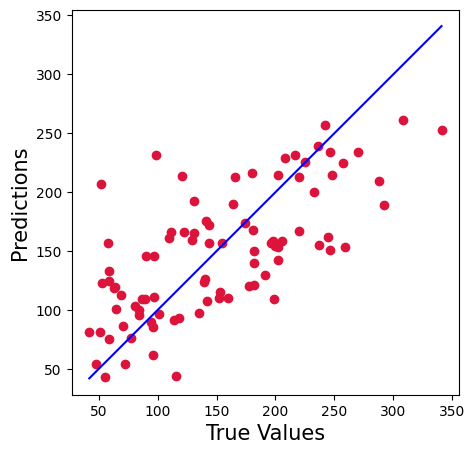

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5,5))
plt.scatter(y_test, yhat_test, c='crimson')

p1 = max(max(yhat_test), max(y_test))
p2 = min(min(yhat_test), min(y_test))
plt.plot([p1, p2], [p1, p2], 'b-')
plt.xlabel('True Values', fontsize=15)
plt.ylabel('Predictions', fontsize=15)
plt.axis('equal')
plt.show()


In [20]:
X_train[0]

my_sample = np.array([3, -0.3, -0.95877769, -1.07310168, -0.71363498,
       -0.94063341, -0.75663014,  0.30179749, -0.77440695, -1.36631681,
       -0.59408791])

Text(0, 0.5, 'y')

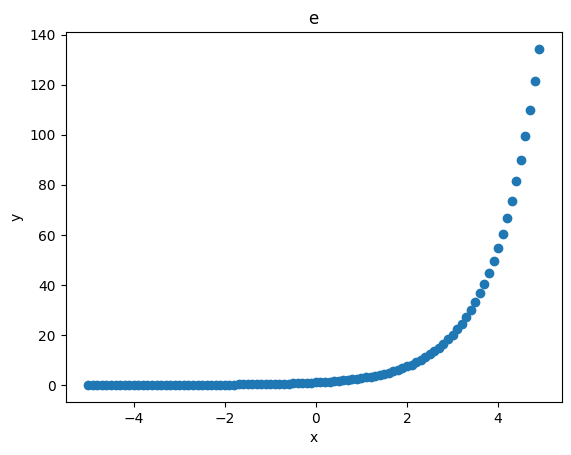

In [21]:
# test for euler
import numpy as np
import matplotlib.pyplot as plt

euler = lambda x: np.exp(x) #lambda function
x = np.arange(-5,5,0.1)
y = euler(x)

# Plot the sigmoid
plt.scatter(x, y)
plt.title('e')
plt.xlabel('x')
plt.ylabel('y')

Text(0, 0.5, 'y')

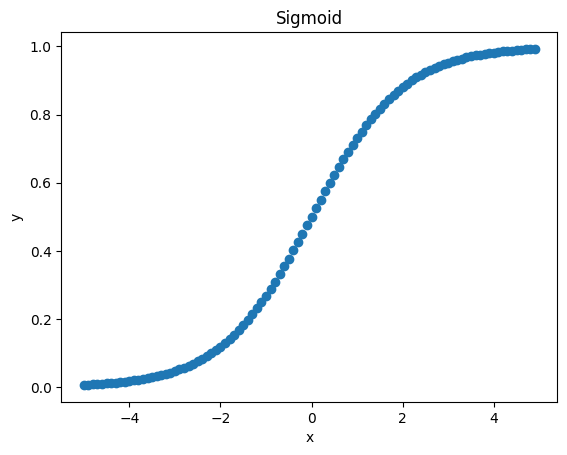

In [22]:
##### Sigmoid
sigmoid_gen = lambda x: (1+np.exp(-x))**-1

# Function way
def sigmoid(x):
    sig = 1 / (1 + np.exp(-x))
    return sig

# Generate data points
x = np.arange(-5,5,0.1)
y = sigmoid(x)

# Plot the sigmoid
plt.scatter(x, y)
plt.title('Sigmoid')
plt.xlabel('x')
plt.ylabel('y')

Text(0, 0.5, 'y')

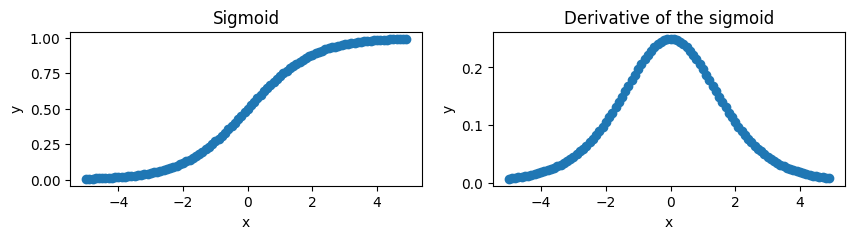

In [23]:
 # Formula:
# g(x) = 1 / (1 + np.exp(-x))

# lambda way 
sigmoid_gen = lambda x: (1+np.exp(-x))**-1

# Function way
def sigmoid(x, deriv = False):
    sig = 1 / (1 + np.exp(-x))
    if deriv:
        sig_deriv = sig*(1-sig) 
        return sig_deriv
    else:
        return sig
# Generate data points
x = np.arange(-5,5,0.1)
y = sigmoid(x)
y_deriv = sigmoid(x, deriv = True)

# Plot the sigmoid
_, ax = plt.subplots(1, 2, figsize=(10, 2))
ax1 = ax[0]
ax1.scatter(x, y)
ax1.set_title('Sigmoid')
ax1.set_xlabel('x')
ax1.set_ylabel('y')

# Plot the derivative of the sigmoid
ax2 = ax[1]
ax2.scatter(x, y_deriv)
ax2.set_title('Derivative of the sigmoid')
ax2.set_xlabel('x')
ax2.set_ylabel('y')
